# Week 2 Iinternship
Deep Exploratory Analysis & Feature Engineering

Objectives
The objectives of this noteboob is to perform exploratory data analysis (EDA)
and feature engineering on the steel Industry Energy consumption dataset.
Include data inspection, feature creation, outlier detection, correlation analysis,
and visualization to understand the factors affecting energy consumption.

In [1]:
#inport the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

In [2]:
df=pd.read_csv('Steel_industry_data.csv')

In [3]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


shape the data set

In [4]:
df.shape

(35040, 11)

in dataset 11 columns and 35040 rows

next find information of dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

find the statistical summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2(tCO2),35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00


check the missing values

In [7]:
df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

no missing values in dataset mentioned above

check the duplicate rows

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

zero duplicate rows

# Feature engineering
In this section, we will create new feature from the existing date column to improve the predictive power of our machine learning models

convert date column to datetime

In [10]:
df["date"]=pd.to_datetime(df["date"],dayfirst=True,errors="coerce")
df["date"].head()

0   2018-01-01 00:15:00
1   2018-01-01 00:30:00
2   2018-01-01 00:45:00
3   2018-01-01 01:00:00
4   2018-01-01 01:15:00
Name: date, dtype: datetime64[ns]

In [11]:
# extract hour
df["Hour"]=df["date"].dt.hour
df["Hour"].head()

0    0
1    0
2    0
3    1
4    1
Name: Hour, dtype: int32

# Extract the month

In [12]:
df["Month"]=df["date"].dt.month_name()
df["Month"].head()

0    January
1    January
2    January
3    January
4    January
Name: Month, dtype: object

create the Weekday / weekend feature 


In [13]:
df["daytype"]=np.where(
    df["date"].dt.day_of_week < 5,
    "weekday",
    "weekend"
)
df["daytype"].value_counts()

daytype
weekday    25056
weekend     9984
Name: count, dtype: int64

# power Factor Ratio
A new feature called Power factor ratio is created by dividing the leading power factor and lagging power factor


In [14]:
df["Power_factor_Ratio"]=(df["Leading_Current_Power_Factor"]/df["Lagging_Current_Power_Factor"])
df["Power_factor_Ratio"].head()

0    1.365934
1    1.497679
2    1.422880
3    1.468644
4    1.545117
Name: Power_factor_Ratio, dtype: float64

# High Load Feature
Rows having energy consumption greater than the 75th percentile are labled as "highlaod=1"
otherwise "0"

In [15]:
threshold=df["Usage_kWh"].quantile(0.75)
threshold

np.float64(51.2375)

create the highload feature

In [16]:
df["High_Load"]=np.where(
    df["Usage_kWh"]>threshold,
    1,0
)
df["High_Load"].head()

0    0
1    0
2    0
3    0
4    0
Name: High_Load, dtype: int64

check the newly created feature

In [17]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,daytype,Power_factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,weekday,1.545117,0


# Outlier Detection
In this section we will detect outlier in the "Usage_Kwh" column using the interquartile range(iqr) method

In [18]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'daytype',
       'Power_factor_Ratio', 'High_Load'],
      dtype='object')

calculate the Q1, Q3,and IQR

In [19]:
q1=df["Usage_kWh"].quantile(0.25)
q3=df["Usage_kWh"].quantile(0.75)
iqr=q3-q1
q1


np.float64(3.2)

In [20]:
q3

np.float64(51.2375)

In [21]:
iqr

np.float64(48.037499999999994)

calculate the uper and lower bound

In [22]:
lower_bound=q1-1.5*iqr
uper_bound=q3+1.5*iqr


In [23]:
lower_bound

np.float64(-68.85624999999999)

In [24]:
uper_bound

np.float64(123.29374999999999)

Detect the outlier 

In [25]:
Outlier=(df["Usage_kWh"]<lower_bound) | (df["Usage_kWh"]>uper_bound)
Outlier.sum()

np.int64(328)

In [26]:
#first 5 outliers display
Outlier.head()

0    False
1    False
2    False
3    False
4    False
Name: Usage_kWh, dtype: bool

Boxplot for Usage_kwh 

Text(0.5, 1.0, 'Boxplot of Usage_KWh')

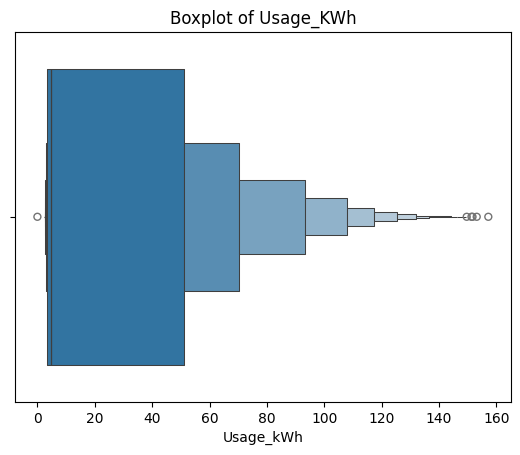

In [27]:
sns.boxenplot(x=df["Usage_kWh"])
plt.title("Boxplot of Usage_KWh")


# Correlation Analysis
Correlation helps us understand the relation ship between numerical feature and the target variable (Usage_kwh)

In [28]:
numerical_df=df.select_dtypes(include=np.number)
numerical_df

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_factor_Ratio,High_Load
0,3.17,2.95,0.00,0.0,73.21,100.00,900,0,1.365934,0
1,4.00,4.46,0.00,0.0,66.77,100.00,1800,0,1.497679,0
2,3.24,3.28,0.00,0.0,70.28,100.00,2700,0,1.422880,0
3,3.31,3.56,0.00,0.0,68.09,100.00,3600,1,1.468644,0
4,3.82,4.50,0.00,0.0,64.72,100.00,4500,1,1.545117,0
...,...,...,...,...,...,...,...,...,...,...
35035,3.85,4.86,0.00,0.0,62.10,100.00,82800,23,1.610306,0
35036,3.74,3.74,0.00,0.0,70.71,100.00,83700,23,1.414227,0
35037,3.78,3.17,0.07,0.0,76.62,99.98,84600,23,1.304881,0
35038,3.78,3.06,0.11,0.0,77.72,99.96,85500,23,1.286155,0


correlation matrix

In [29]:
corr=numerical_df.corr()
corr

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_factor_Ratio,High_Load
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,0.234610,0.234175,-0.090094,0.867840
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,0.082662,0.081250,0.075592,0.825672
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,0.371605,0.372735,-0.779884,-0.294913
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,0.231726,0.231306,-0.082349,0.863164
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,0.565270,0.566544,-0.915117,0.285679
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-0.360563,-0.361409,0.805223,0.296275
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000,0.999186,-0.530254,0.177164
Hour,0.234175,0.081250,0.372735,0.231306,0.566544,-0.361409,0.999186,1.000000,-0.531380,0.176399
Power_factor_Ratio,-0.090094,0.075592,-0.779884,-0.082349,-0.915117,0.805223,-0.530254,-0.531380,1.000000,-0.056465
High_Load,0.867840,0.825672,-0.294913,0.863164,0.285679,0.296275,0.177164,0.176399,-0.056465,1.000000


correlation heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

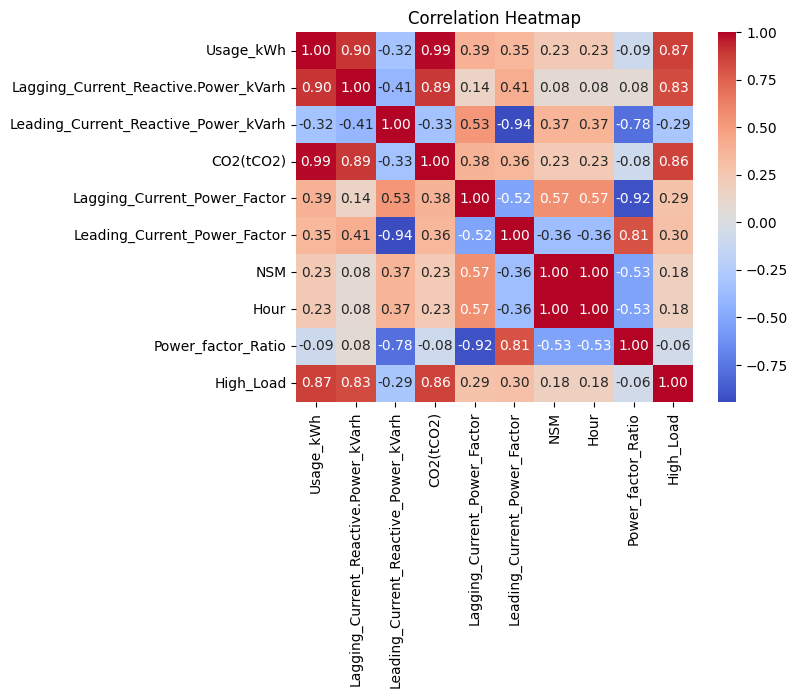

In [30]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

## Observation 
the above output shows the three numerical feature that have the strongest correlation with "Usage_kwh".these variable
are expected to be the most influential predictors for regression models developed in part

# Average Energy consumption by Load Type
This visualization shows the average energy consumption for each load category. It helps identify which load type consume the electricity

In [31]:
# Average Usage by load type
avg_load=df.groupby("Load_Type")["Usage_kWh"].mean()
avg_load

Load_Type
Light_Load       8.626207
Maximum_Load    59.265314
Medium_Load     38.445394
Name: Usage_kWh, dtype: float64

Grouped bar chart

(array([0, 1, 2]),
 [Text(0, 0, 'Light_Load'),
  Text(1, 0, 'Maximum_Load'),
  Text(2, 0, 'Medium_Load')])

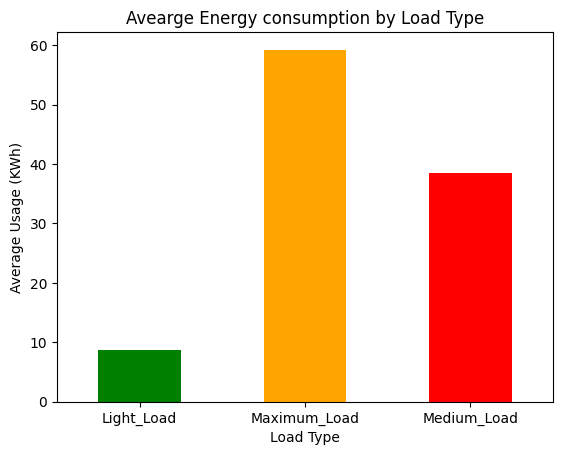

In [32]:
avg_load.plot(kind="bar",color=["green","orange","red"])
plt.title("Avearge Energy consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (KWh)")
plt.xticks(rotation=0)

this chart show how energy consumption changes throughout the day

In [33]:
hourly_usage=df.groupby("Hour")["Usage_kWh"].mean()
hourly_usage

Hour
0      7.870075
1      6.072479
2      4.428390
3      4.358041
4      4.309438
5      4.245548
6      4.223705
7      4.502075
8     37.704795
9     58.551733
10    55.874733
11    57.097459
12    18.461000
13    39.019500
14    56.155260
15    55.637541
16    55.799582
17    43.833096
18    33.020932
19    38.208514
20    37.477226
21    13.777363
22     8.658918
23     7.998014
Name: Usage_kWh, dtype: float64

line chart 

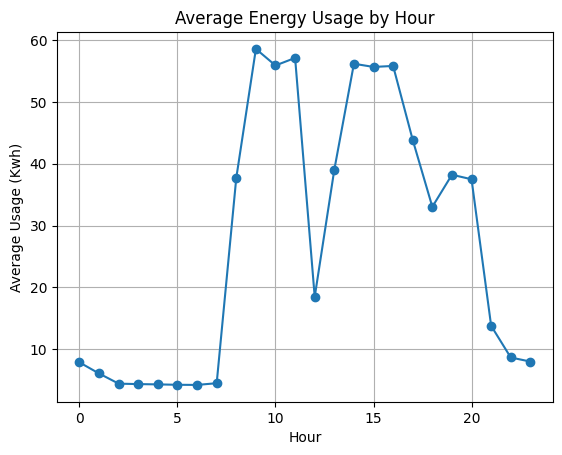

In [34]:
plt.plot(hourly_usage.index,
         hourly_usage.values, marker="o")
plt.title("Average Energy Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Usage (Kwh)")
plt.grid(True)


In [35]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,daytype,Power_factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,weekday,1.545117,0


In [36]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'daytype',
       'Power_factor_Ratio', 'High_Load'],
      dtype='object')

save this dataset in csv file for apply the baseline models

In [37]:
df.to_csv("steel_industry_feature_engineered.csv", index=False)

# Exploratory Data Analysis (EDA) Summary

The Steel Industry Energy Consumption dataset contains operational information related to electricity usage in a manufacturing plant. During the initial analysis, the dataset was examined for missing values, duplicate records, and incorrect data types. The dataset was generally clean, with very few data quality issues. The date column was converted into datetime format, and several useful features such as Hour, DayOfWeek, Month, and DayType were extracted to improve analysis and future model performance.

Feature engineering was also performed by creating a Power Factor Ratio feature and a binary High_Load feature based on the 75th percentile of energy consumption. These engineered features provide additional information about the operating conditions of the plant.

Outlier detection using the IQR method revealed several unusually high energy consumption values. These outliers may represent peak production hours rather than data errors, making them valuable for understanding plant operations.

Correlation analysis identified the three numerical variables that are most strongly associated with Usage_kWh. These features are expected to contribute significantly to predictive modeling.

The grouped bar chart showed that Maximum Load periods consume substantially more electricity than Medium and Light Load periods. Similarly, the hourly line chart indicated clear variations in electricity usage throughout the day, with higher consumption during working hours.

A reasonable hypothesis is that production schedules, equipment utilization, and operational load are the primary drivers of energy consumption spikes within the steel manufacturing process.